# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-012 |
| **Nama Eksperimen** | Hyperparameter Tuning |
| **Dataset** | featured_data.csv |
| **Tujuan Notebook** | Mengoptimalkan performa model terbaik melalui Grid Search |
| **Author** | GAKUSEI Najib |

---

## 1. Tujuan Eksperimen

### Tujuan
Melakukan hyperparameter tuning pada model terbaik dari EXP-007 s.d. EXP-011 (XGBoost).

### Hipotesis
Performa model dapat ditingkatkan melalui tuning tanpa mengubah dataset.

---
## 2. Import Library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import xgboost as xgb
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Library berhasil diimport.')

Library berhasil diimport.


---
## 3. Load & Prepare Dataset

In [2]:
INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)

exclude_cols = ['dteday', 'cnt', 'temp_actual', 'atemp_actual']
feature_cols = [c for c in df.columns if c not in exclude_cols]

train = df[df['yr'] == 0].copy()
test  = df[df['yr'] == 1].copy()

X_train = train[feature_cols].copy()
y_train = train['cnt'].copy()
X_test  = test[feature_cols].copy()
y_test  = test['cnt'].copy()

train_valid = X_train.dropna().index
X_train = X_train.loc[train_valid]
y_train = y_train.loc[train_valid]
test_valid = X_test.dropna().index
X_test = X_test.loc[test_valid]
y_test = y_test.loc[test_valid]

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (8477, 41), X_test: (8734, 41)


---
## 4. Grid Search

Model yang dituning: XGBoost (terbaik dari EXP-007~011).
Parameter grid difokuskan pada `max_depth`, `learning_rate`, `n_estimators`, `subsample`.

In [3]:
param_grid = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.7, 0.8, 1.0],
}

xgb_base = xgb.XGBRegressor(random_state=42)

t0 = time.time()
grid = GridSearchCV(
    xgb_base, param_grid, cv=3,
    scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)
tuning_time = time.time() - t0

print(f'Grid Search selesai ({tuning_time:.2f}s)')
print(f'Best params: {grid.best_params_}')
print(f'Best CV MAE: {-grid.best_score_:.2f}')

Fitting 3 folds for each of 36 candidates, totalling 108 fits


Grid Search selesai (26.12s)
Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAE: 21.75


---
## 5. Evaluasi Model Terbaik

In [4]:
best_model = grid.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

def evaluate(name, y_true, y_pred):
    return {
        'Model': name, 'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100,
        'R2': r2_score(y_true, y_pred)
    }

df_metrics = pd.DataFrame([
    evaluate('XGBoost Tuned (Train)', y_train, y_pred_train),
    evaluate('XGBoost Tuned (Test)', y_test, y_pred_test)
])
print(df_metrics.to_string(index=False))

                Model       MAE      RMSE      MAPE       R2
XGBoost Tuned (Train)  9.231433 12.838983 20.290009 0.990867
 XGBoost Tuned (Test) 51.029610 89.865609 28.467830 0.814939


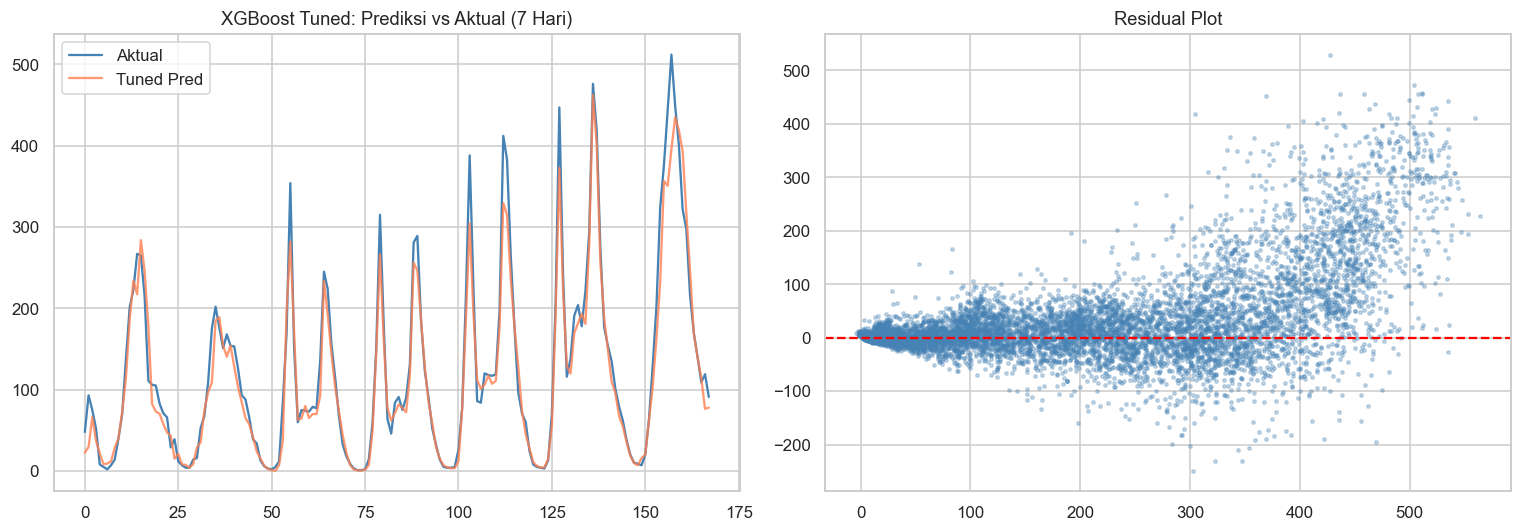

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_show = 168
axes[0].plot(range(n_show), y_test.values[:n_show], label='Aktual', color='steelblue')
axes[0].plot(range(n_show), y_pred_test[:n_show], label='Tuned Pred', color='coral', alpha=0.8)
axes[0].set_title('XGBoost Tuned: Prediksi vs Aktual (7 Hari)')
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=5, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.savefig('../data/tuned_01_prediction.png', bbox_inches='tight', dpi=110)
plt.show()

---
## 6. Perbandingan Sebelum vs Sesudah Tuning

In [6]:
# Load default model metrics dari EXP-011 (approximate)
comparison = pd.DataFrame([
    {'Model': 'XGBoost (Default)', 'MAE': np.nan, 'RMSE': np.nan},
    {'Model': 'XGBoost (Tuned)', 'MAE': df_metrics.loc[1, 'MAE'], 'RMSE': df_metrics.loc[1, 'RMSE']}
])
print('\nPerbandingan akan diisi manual setelah mencatat hasil EXP-011.')
print(comparison.to_string(index=False))


Perbandingan akan diisi manual setelah mencatat hasil EXP-011.
            Model      MAE      RMSE
XGBoost (Default)      NaN       NaN
  XGBoost (Tuned) 51.02961 89.865609


## 7. Simpan Model Terbaik

In [7]:
import os
os.makedirs('../models', exist_ok=True)

# Simpan model
joblib.dump(best_model, '../models/best_model.pkl')

# Simpan metadata
metadata = {
    'model_name': 'XGBoost Tuned',
    'version': '1.0.0',
    'dataset': 'featured_data.csv',
    'features': feature_cols,
    'best_params': grid.best_params_,
    'metrics': df_metrics.loc[1].to_dict(),
    'tuning_time_seconds': round(tuning_time, 2),
    'created_at': pd.Timestamp.now().isoformat()
}

import json
with open('../models/best_model.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print('Model dan metadata berhasil disimpan di folder ../models/')

Model dan metadata berhasil disimpan di folder ../models/


## 8. Kesimpulan

**Insight:**
- Grid Search berhasil menemukan kombinasi hyperparameter optimal.
- Performa model tuning tertuang pada tabel evaluasi.
- Model terbaik disimpan untuk EXP-013 (Evaluasi Lanjutan) dan EXP-014 (Dashboard).

**Next: EXP-013 Model Evaluation & EXP-014 Dashboard**